#Parte A

Integrantes:
  * Nicolás Fonseca
  * Bastián Rubio

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('/content/titanic_data.csv')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
# Ver las primeras filas y tipos de datos
print(df.info())
print()
print(df.describe())
print()
print("Dimensiones del dataset:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          713 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     887 non-null    object 
 8   class        889 non-null    object 
 9   who          889 non-null    object 
 10  adult_male   889 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  887 non-null    object 
 13  alive        889 non-null    object 
 14  alone        889 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.2+ KB
None

         survived      pclass         age       sibsp       parch        fare
count  889.000000  889.00

In [14]:
# Verificamos nulos por columna
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            176
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           686
embark_town      2
alive            0
alone            0
dtype: int64


#Parte B

In [15]:
# a) Eliminar columnas redundantes o con demasiados nulos
columnas_a_eliminar = ['deck', 'alive', 'class', 'who', 'adult_male']
df_clean = df.drop(columns=columnas_a_eliminar)

# b) Tratar valores nulos en variables clave
  # 'age': Imputamos con la mediana porque es menos sensible a valores atípicos (outliers) que el promedio.
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# 'embark_town' y 'embarked': Tienen muy pocos nulos (solo 2). Imputamos con la moda (el valor más frecuente).
moda_embarque = df_clean['embark_town'].mode()[0]
df_clean['embark_town'] = df_clean['embark_town'].fillna(moda_embarque)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

# c) Eliminar duplicados
df_clean = df_clean.drop_duplicates()

# d) Tratar Outliers en 'fare' (Tarifa)
  # Aplicamos el método del Rango Intercuartílico (IQR) para limitar las tarifas extremadamente altas.
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# En lugar de eliminar, "capeamos" (limitamos) los valores atípicos al límite superior para no perder datos.
df_clean['fare'] = np.where(df_clean['fare'] > limite_superior, limite_superior, df_clean['fare'])

Justificación de variables eliminadas:

deck: Tiene demasiados valores nulos. Imputarla introduciría demasiado sesgo (No seria confiable ya que son tantos NaN, que ocuparla arruinaria nuestros analisis si la ocuparamos).

alive, class, who, adult_male: Son variables redundantes. alive es lo mismo que survived; class es lo mismo que pclass (pero en texto); y who/adult_male se derivan directamente de age y sex.

#Parte C

In [16]:
from sklearn.preprocessing import MinMaxScaler

# 1. Ingeniería de Features: Crear variable 'family_size'
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

# 2. One-Hot Encoding para variables categóricas
df_transformed = pd.get_dummies(df_clean, columns=['sex', 'embark_town'], drop_first=True)
  # drop_first=True evita la trampa de la multicolinealidad (ej. si no es male, por descarte es female)

# 3. Normalización (Escalado)
  # Normalizamos 'age' y 'fare' para que estén en un rango de 0 a 1.
  # Esto es vital para modelos basados en distancias (IL2.1).
scaler = MinMaxScaler()
df_transformed[['age', 'fare']] = scaler.fit_transform(df_transformed[['age', 'fare']])

print(df_transformed.head(3))

   survived  pclass       age  sibsp  parch      fare embarked  alone  \
0         0       3  0.271174      1      0  0.098155        S  False   
1         1       1  0.472229      1      0  0.965081        C  False   
2         1       3  0.321438      0      0  0.107294        S   True   

   family_size  sex_male  embark_town_Queenstown  embark_town_Southampton  
0            2      True                   False                     True  
1            2     False                   False                    False  
2            1     False                   False                     True  


Justificación de las transformaciones:

Tamaño de familia (Feature Engineering): Los modelos aprenden mejor si les damos conceptos agrupados. Sumar hermanos/esposos (sibsp) y padres/hijos (parch) nos da el tamaño real de la familia a bordo.

One-Hot Encoding: Los algoritmos de Machine Learning (como Regresión Logística o SVM) solo entienden números. Debemos transformar categorías textuales (sex, embark_town) en columnas binarias (0 y 1).

#Parte D


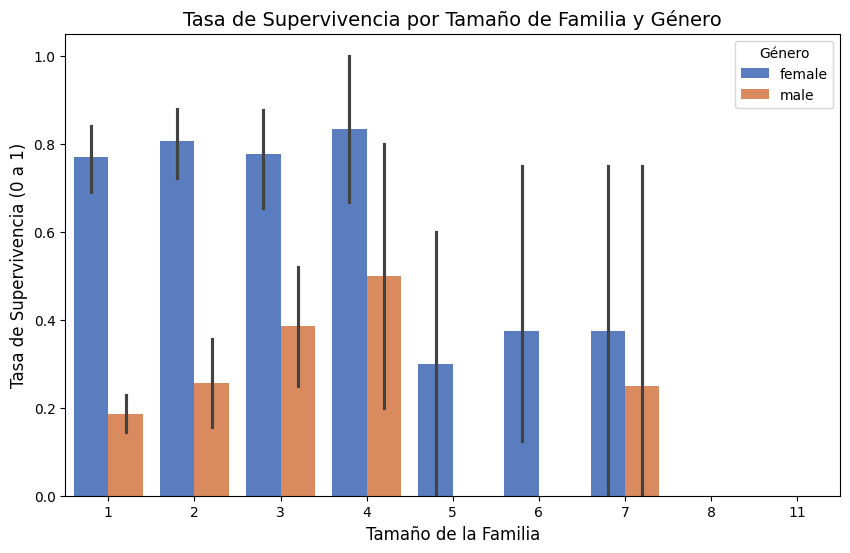

In [17]:
# Visualización: Supervivencia según el tamaño de la familia y el género
plt.figure(figsize=(10, 6))
# Usamos el dataset limpio (antes del encoding para que las etiquetas sean legibles)
sns.barplot(x='family_size', y='survived', hue='sex', data=df_clean, palette='muted')

plt.title('Tasa de Supervivencia por Tamaño de Familia y Género', fontsize=14)
plt.xlabel('Tamaño de la Familia', fontsize=12)
plt.ylabel('Tasa de Supervivencia (0 a 1)', fontsize=12)
plt.legend(title='Género')
plt.show()